# 02 — EDA y Pipeline de Limpieza

**Proyecto:** FinBalance — Predicción de Fragilidad Financiera  
**Dataset:** Encuesta de Demanda de Servicios Financieros 2022 (Banca de las Oportunidades)  
**Objetivo:** Limpiar, explorar y preparar el dataset para el entrenamiento del modelo.

---

### Contenido
1. Carga y diagnóstico inicial  
2. Limpieza de calidad (NS/NR, tipos, normalización)  
3. Análisis Exploratorio (EDA)  
4. Imputación por estrategia  
5. Codificación y preparación para modelado  
6. Guardado del dataset procesado

---
## 0 — Imports y configuración

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

AZUL  = '#1F4E79'
TEAL  = '#1D9E75'
CORAL = '#D95A30'
AMBER = '#BA7517'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

RUTA_RAW       = Path('../data/raw/Encuesta_demanda_2022_microdatos.xlsx')
RUTA_PROCESSED = Path('../data/processed')
RUTA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Variables binarias Sí/No que se normalizarán en el paso 2.3
COLS_BIN = [
    'prod_cuenta_ahorro',    # T101_1
    'prod_tarjeta_debito',   # T101_2
    'gasto_entretenimiento', # T211_10
    'gasto_prod_financieros',# T211_11
]

print('Configuración lista.')


Configuración lista.


---
## 1 — Carga y diagnóstico inicial

In [40]:
# Variables seleccionadas: Top 20 del análisis de V de Cramér
# (Seleccion_variables_fragilidad_financiera_EDF2022.xlsx — hoja Top20_Recomendadas)
# Total: 20 features + 1 target = 21 columnas del raw

cols_needed = [
    'P407',     # TARGET: cuánto tiempo podría sostenerse sin ingresos
    # Ingresos (2)
    'P714',     # rango de ingresos mensuales del hogar          [V Cramér: 0.210]
    'P716',     # frecuencia con que recibe ingresos             [V Cramér: 0.074]
    # Ahorro (2)
    'P109_1',   # cómo ahorra (si ahorra o no)                  [V Cramér: 0.192]
    'P404_1',   # recursos planeados para jubilación             [V Cramér: 0.167]
    # Gastos (2)
    'T211_10',  # pagó entretenimiento en el último año          [V Cramér: 0.215]
    'T211_11',  # pagó productos financieros en el último año    [V Cramér: 0.180]
    # Productos financieros (2)
    'T101_1',   # tiene cuenta de ahorro                        [V Cramér: 0.140]
    'T101_2',   # tiene tarjeta débito                          [V Cramér: 0.142]
    # Comportamiento crediticio y pagos (3)
    'T402_2',   # le falta dinero al final del mes              [V Cramér: 0.215]
    'T402_3',   # frecuencia de atraso en pagos                 [V Cramér: 0.123]
    'P301',     # solicitó crédito en el último año              [V Cramér: 0.095]
    # Hábitos y percepciones (5)
    'T401_1',   # podría afrontar un gasto imprevisto           [V Cramér: 0.147]
    'T401_2',   # está asegurando su futuro financiero          [V Cramér: 0.172]
    'T405_1',   # maneja presupuesto o plan (escala 1-5)         [V Cramér: 0.115]
    'T405_3',   # deuda es manejable (escala 1-5)               [V Cramér: 0.120]
    'T405_8',   # control sobre su situación financiera (1-5)   [V Cramér: 0.168]
    # Sociodemográficas (4)
    'P708',     # nivel educativo más alto alcanzado             [V Cramér: 0.168]
    'P710',     # miembros del hogar con empleo estable          [V Cramér: 0.107]
    'GENERO',   # género                                        [V Cramér: 0.147]
    'ESTRATO',  # estrato socioeconómico                        [V Cramér: 0.096]
]

df = pd.read_excel(RUTA_RAW, usecols=lambda c: c in cols_needed)
df = df[cols_needed]   # reordenar según cols_needed (usecols no garantiza orden)

df = df.rename(columns={
    'P407'   : 'fragilidad_financiera',
    # Ingresos
    'P714'   : 'rango_ingresos',
    'P716'   : 'frec_ingresos',
    # Ahorro
    'P109_1' : 'ahorro_metodo',
    'P404_1' : 'plan_jubilacion',
    # Gastos
    'T211_10': 'gasto_entretenimiento',
    'T211_11': 'gasto_prod_financieros',
    # Productos financieros
    'T101_1' : 'prod_cuenta_ahorro',
    'T101_2' : 'prod_tarjeta_debito',
    # Comportamiento crediticio y pagos
    'T402_2' : 'comp_falta_dinero',
    'T402_3' : 'comp_atraso_pagos',
    'P301'   : 'solicito_credito',
    # Hábitos y percepciones
    'T401_1' : 'perc_puede_imprevisto',
    'T401_2' : 'perc_asegura_futuro',
    'T405_1' : 'perc_maneja_presupuesto',
    'T405_3' : 'perc_deuda_manejable',
    'T405_8' : 'perc_control_sit',
    # Sociodemográficas
    'P708'   : 'nivel_educativo',
    'P710'   : 'miembros_empleo_estable',
    'GENERO' : 'genero',
    'ESTRATO': 'estrato',
})

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Features (20): {[c for c in df.columns if c != "fragilidad_financiera"]}')


Dataset cargado: 5,610 filas x 21 columnas
Features (20): ['rango_ingresos', 'frec_ingresos', 'ahorro_metodo', 'plan_jubilacion', 'gasto_entretenimiento', 'gasto_prod_financieros', 'prod_cuenta_ahorro', 'prod_tarjeta_debito', 'comp_falta_dinero', 'comp_atraso_pagos', 'solicito_credito', 'perc_puede_imprevisto', 'perc_asegura_futuro', 'perc_maneja_presupuesto', 'perc_deuda_manejable', 'perc_control_sit', 'nivel_educativo', 'miembros_empleo_estable', 'genero', 'estrato']


In [41]:
print(f'Shape: {df.shape}')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())
print()
df.head(3)

Shape: (5610, 21)

Tipos de datos:
object    21
Name: count, dtype: int64



,fragilidad_financiera,rango_ingresos,frec_ingresos,ahorro_metodo,plan_jubilacion,gasto_entretenimiento,gasto_prod_financieros,prod_cuenta_ahorro,prod_tarjeta_debito,comp_falta_dinero,...,solicito_credito,perc_puede_imprevisto,perc_asegura_futuro,perc_maneja_presupuesto,perc_deuda_manejable,perc_control_sit,nivel_educativo,miembros_empleo_estable,genero,estrato
0,Una semana,Entre 500.001 y 750.000,Irregularmente,"Guardando en la casa (Alcancía, “debajo del co...",Continuar trabajando,No,No,NO,NO,Siempre,...,No y tampoco tengo otros créditos,Muy poco,Nada,5,5,1,Secundaria,Uno,Femenino,1
1,Un mes,Entre 750.001 y 1.000.000,Irregularmente,"No guardo, ni ahorro, ni invierto, ni separo",Ninguna,Sí,No,NO,NO,Siempre,...,No y tampoco tengo otros créditos,Nada,Nada,4,3,5,Primaria,Uno,Femenino,1
2,Un mes,Entre 500.001 y 750.000,Mensual,"No guardo, ni ahorro, ni invierto, ni separo",No sabe / no responde,No,No,NO,SÍ,Casi siempre,...,Sí y además tengo otros créditos,Muy bien,Muy bien,5,5,1,Primaria,Ninguno,Femenino,1


In [42]:
# Diagnóstico de nulos
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
resumen_nulos = (pd.DataFrame({'nulos': nulos, 'pct_%': pct})
                 .query('nulos > 0')
                 .sort_values('pct_%', ascending=False))
print(f'Variables con nulos reales: {len(resumen_nulos)} / {len(df.columns)}')
print(f'Total nulos: {nulos.sum():,}\n')
print(resumen_nulos.to_string())

Variables con nulos reales: 0 / 21
Total nulos: 0

Empty DataFrame
Columns: [nulos, pct_%]
Index: []


In [43]:
# Duplicados
dup = df.duplicated().sum()
print(f'Registros duplicados exactos: {dup}')
if dup > 0:
    df = df.drop_duplicates(keep='first')
    print(f'  Eliminados. Filas restantes: {len(df):,}')
else:
    print('  Sin duplicados — OK')

Registros duplicados exactos: 0
  Sin duplicados — OK


---
## 2 — Limpieza de calidad de datos

El dataset es una encuesta institucional con 6 formatos distintos de NS/NR
(no-respuesta). Ninguno es `NaN` real — deben convertirse antes de cualquier análisis.

| Problema | Técnica |
|---|---|
| NS/NR en 6 formatos (texto plano, con HTML, con código) | Detección por patrón → `NaN` |
| Escalas `T405_x` (1–5) guardadas como `str` | `pd.to_numeric()` |
| `'SÍ'`/`'NO'` (mayúsculas en T101_x) vs `'Sí'`/`'No'` | Normalización binaria |
| `estrato` con texto mezclado | Limpieza → numérico |

In [44]:
# 2.1 NS/NR → NaN  (6 formatos de encuesta, incluyendo tags HTML)
def es_nsnr(v):
    if pd.isnull(v): return False
    s = re.sub(r'<[^>]+>', '', str(v)).strip()
    return s in [
        'NS/NR (E: No lea esta opción)', 'NS/NR (E: No leer)',
        '9 (NS/NR)', 'NS/NR', 'No tiene',
    ]

nulos_antes = df.isnull().sum().sum()
for col in df.columns:
    mask = df[col].apply(es_nsnr)
    if mask.sum() > 0:
        df.loc[mask, col] = np.nan
        print(f'  [{col}] {mask.sum()} NS/NR → NaN')

print(f'\nNS/NR convertidos : {df.isnull().sum().sum() - nulos_antes:,}')
print(f'Total nulos ahora  : {df.isnull().sum().sum():,}')

  [fragilidad_financiera] 383 NS/NR → NaN
  [rango_ingresos] 241 NS/NR → NaN
  [frec_ingresos] 399 NS/NR → NaN
  [prod_cuenta_ahorro] 4 NS/NR → NaN
  [prod_tarjeta_debito] 3 NS/NR → NaN
  [solicito_credito] 78 NS/NR → NaN
  [perc_maneja_presupuesto] 91 NS/NR → NaN
  [perc_deuda_manejable] 106 NS/NR → NaN
  [perc_control_sit] 101 NS/NR → NaN
  [nivel_educativo] 6 NS/NR → NaN
  [miembros_empleo_estable] 31 NS/NR → NaN
  [estrato] 286 NS/NR → NaN

NS/NR convertidos : 1,729
Total nulos ahora  : 1,729


In [45]:
# 2.2 Escalas ordinales T405_x: string '1'..'5' → numérico
# El '9 (NS/NR)' ya fue convertido a NaN en el paso anterior
cols_escala = ['perc_maneja_presupuesto', 'perc_deuda_manejable', 'perc_control_sit']
for col in cols_escala:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    unicos = sorted(df[col].dropna().unique().astype(int))
    print(f'[{col}] valores: {unicos} | NaN: {df[col].isnull().sum()}')


[perc_maneja_presupuesto] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 91
[perc_deuda_manejable] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 106
[perc_control_sit] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 101


In [46]:
# 2.3 Normalizar respuestas binarias: 'SÍ'/'NO' (T101_x, T211_x) → 'Sí'/'No'
def norm_binaria(v):
    if pd.isnull(v): return np.nan
    s = str(v).strip()
    if s in ('SÍ', 'Sí', 'SI'): return 'Sí'
    if s in ('NO', 'No'):        return 'No'
    return np.nan

for col in COLS_BIN:
    df[col] = df[col].apply(norm_binaria)

print('Normalización binaria completada.')
for col in COLS_BIN:
    print(f'  {col}: {df[col].value_counts(dropna=False).to_dict()}')


Normalización binaria completada.
  prod_cuenta_ahorro: {'No': 3608, 'Sí': 1998, nan: 4}
  prod_tarjeta_debito: {'No': 4325, 'Sí': 1282, nan: 3}
  gasto_entretenimiento: {'No': 3717, 'Sí': 1893}
  gasto_prod_financieros: {'No': 4801, 'Sí': 809}


In [47]:
# 2.4 Estrato → numérico (los 'NS/NR' y 'No tiene' ya son NaN)
df['estrato'] = pd.to_numeric(df['estrato'], errors='coerce')
print('estrato → numérico:')
print(df['estrato'].value_counts(dropna=False).sort_index())

estrato → numérico:
estrato
1.0    1979
2.0    2052
3.0    1027
4.0     169
5.0      61
6.0      36
NaN     286
Name: count, dtype: int64


In [48]:
# Resumen post-limpieza
nulos_post = df.isnull().sum()
pct_post   = (nulos_post / len(df) * 100).round(1)
resumen_post = (pd.DataFrame({'nulos': nulos_post, 'pct_%': pct_post})
                .query('nulos > 0').sort_values('pct_%', ascending=False))
print('Nulos tras limpieza:')
print(resumen_post.to_string())
print(f'\nTotal filas: {len(df):,} | Variables con nulos: {len(resumen_post)}')

Nulos tras limpieza:
                         nulos  pct_%
frec_ingresos              399    7.1
fragilidad_financiera      383    6.8
estrato                    286    5.1
rango_ingresos             241    4.3
perc_deuda_manejable       106    1.9
perc_control_sit           101    1.8
perc_maneja_presupuesto     91    1.6
solicito_credito            78    1.4
miembros_empleo_estable     31    0.6
prod_cuenta_ahorro           4    0.1
prod_tarjeta_debito          3    0.1
nivel_educativo              6    0.1

Total filas: 5,610 | Variables con nulos: 12


---
## 3 — Análisis Exploratorio (EDA)

Cuatro visualizaciones clave para entender la distribución del problema
antes de entrenar el modelo.

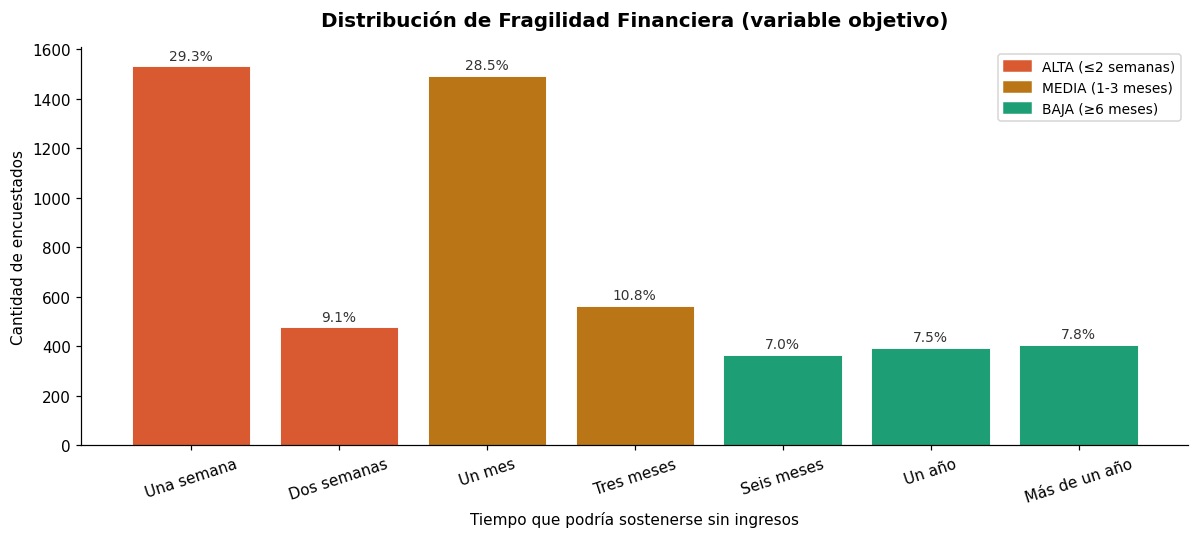

NS/NR excluidos del gráfico: 383


In [49]:
# 3.1 Distribución de la variable objetivo
orden = ['Una semana','Dos semanas','Un mes','Tres meses',
         'Seis meses','Un año','Más de un año']
conteo = df['fragilidad_financiera'].value_counts()
conteo = conteo.reindex([x for x in orden if x in conteo.index])
colores_barra = [CORAL]*2 + [AMBER]*2 + [TEAL]*3

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(conteo.index, conteo.values, color=colores_barra, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, conteo.values):
    pct = val / conteo.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#333')
ax.set_title('Distribución de Fragilidad Financiera (variable objetivo)', pad=14)
ax.set_xlabel('Tiempo que podría sostenerse sin ingresos')
ax.set_ylabel('Cantidad de encuestados')
ax.tick_params(axis='x', rotation=18)
leyenda = [mpatches.Patch(color=CORAL, label='ALTA (≤2 semanas)'),
           mpatches.Patch(color=AMBER, label='MEDIA (1-3 meses)'),
           mpatches.Patch(color=TEAL,  label='BAJA (≥6 meses)')]
ax.legend(handles=leyenda, fontsize=9)
plt.tight_layout()
plt.savefig('../docs/viz_01_fragilidad_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'NS/NR excluidos del gráfico: {df["fragilidad_financiera"].isnull().sum()}')

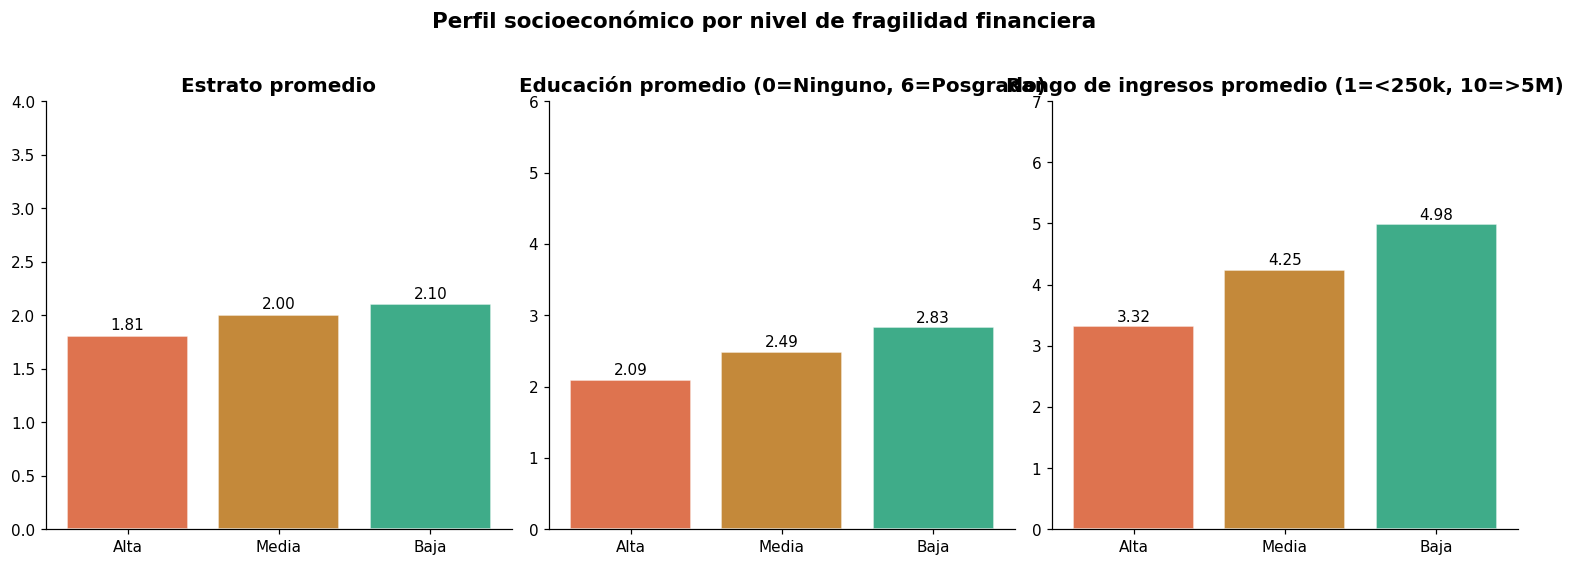

In [50]:
# 3.2 Perfil socioeconómico por nivel de fragilidad
mapa_nivel = {'Una semana':'Alta','Dos semanas':'Alta',
              'Un mes':'Media','Tres meses':'Media',
              'Seis meses':'Baja','Un año':'Baja','Más de un año':'Baja'}
df['nivel_fragilidad'] = df['fragilidad_financiera'].map(mapa_nivel)
orden_niv = ['Alta','Media','Baja']
col_niv   = [CORAL, AMBER, TEAL]
dv = df.dropna(subset=['nivel_fragilidad'])

mapa_edu_viz = {'Ninguno':0,'Primaria':1,'Secundaria':2,
                'Técnico':3,'Tecnólogos':4,'Universitarios':5,'Posgrado':6}
dv2 = dv.copy()
dv2['edu_num'] = dv2['nivel_educativo'].map(mapa_edu_viz)

mapa_ing_viz = {
    'Menos de 250.000':1,'Entre 250.001 y 500.000':2,'Entre 500.001 y 750.000':3,
    'Entre 750.001 y 1.000.000':4,'Entre 1.000.001 y 1.500.000':5,
    'Entre 1.500.001 y 2.000.000':6,'Entre 2.000.001 y 3.000.000':7,
    'Entre 3.000.001 y 4.000.000':8,'Entre 4.000.001 y 5.000.000':9,'Más de 5.000.000':10,
}
dv2['ing_num'] = dv2['rango_ingresos'].map(mapa_ing_viz)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Estrato promedio
est_niv = dv2.groupby('nivel_fragilidad')['estrato'].mean().reindex(orden_niv)
axes[0].bar(orden_niv, est_niv.values, color=col_niv, alpha=0.85, edgecolor='white')
for i, val in enumerate(est_niv.values):
    axes[0].text(i, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Estrato promedio'); axes[0].set_ylim(0, 4)

# Nivel educativo promedio
edu_niv = dv2.groupby('nivel_fragilidad')['edu_num'].mean().reindex(orden_niv)
axes[1].bar(orden_niv, edu_niv.values, color=col_niv, alpha=0.85, edgecolor='white')
for i, val in enumerate(edu_niv.values):
    axes[1].text(i, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Educación promedio (0=Ninguno, 6=Posgrado)'); axes[1].set_ylim(0, 6)

# Rango de ingresos promedio
ing_niv = dv2.groupby('nivel_fragilidad')['ing_num'].mean().reindex(orden_niv)
axes[2].bar(orden_niv, ing_niv.values, color=col_niv, alpha=0.85, edgecolor='white')
for i, val in enumerate(ing_niv.values):
    axes[2].text(i, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[2].set_title('Rango de ingresos promedio (1=<250k, 10=>5M)'); axes[2].set_ylim(0, 7)

plt.suptitle('Perfil socioeconómico por nivel de fragilidad financiera',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/viz_02_perfil_demografico.png', dpi=120, bbox_inches='tight')
plt.show()


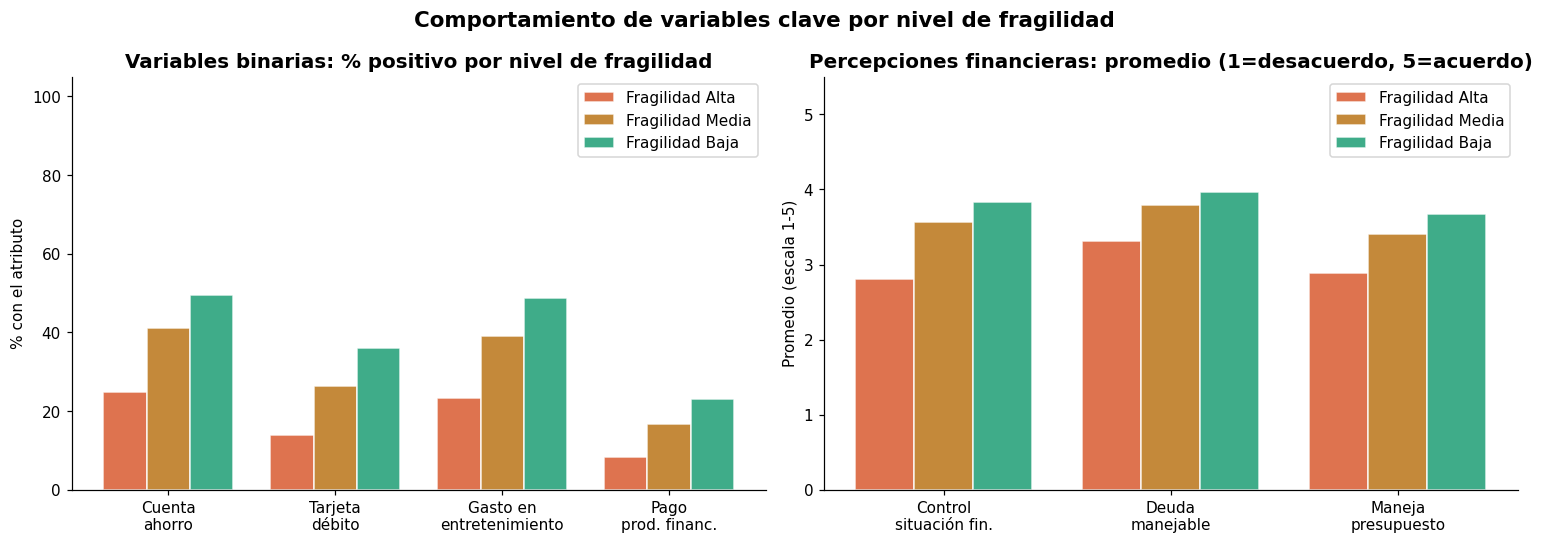

In [51]:
# 3.3 Comportamiento de variables clave por nivel de fragilidad
# Muestra tasas de tenencia / hábitos positivos en cada grupo

vars_bin = ['prod_cuenta_ahorro','prod_tarjeta_debito','gasto_entretenimiento','gasto_prod_financieros']
nombres_bin = ['Cuenta\nahorro','Tarjeta\ndébito','Gasto en\nentretenimiento','Pago\nprod. financ.']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: variables binarias (% con Sí)
x = np.arange(len(vars_bin)); width = 0.26
for i, (nivel, color) in enumerate(zip(orden_niv, col_niv)):
    sub  = dv[dv['nivel_fragilidad'] == nivel]
    pcts = [(sub[c] == 'Sí').sum() / len(sub) * 100 for c in vars_bin]
    axes[0].bar(x + i*width, pcts, width, label=f'Fragilidad {nivel}',
                color=color, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x + width); axes[0].set_xticklabels(nombres_bin, ha='center')
axes[0].set_ylabel('% con el atributo'); axes[0].set_ylim(0, 105)
axes[0].set_title('Variables binarias: % positivo por nivel de fragilidad')
axes[0].legend()

# Panel der: percepciones (escala 1-5), promedio por nivel
vars_perc = ['perc_control_sit','perc_deuda_manejable','perc_maneja_presupuesto']
nombres_perc = ['Control\nsituación fin.','Deuda\nmanejable','Maneja\npresupuesto']
x2 = np.arange(len(vars_perc))
for i, (nivel, color) in enumerate(zip(orden_niv, col_niv)):
    sub   = dv[dv['nivel_fragilidad'] == nivel]
    medias = []
    for c in vars_perc:
        vals = pd.to_numeric(sub[c], errors='coerce').dropna()
        medias.append(vals.mean() if len(vals) > 0 else 0)
    axes[1].bar(x2 + i*width, medias, width, label=f'Fragilidad {nivel}',
                color=color, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x2 + width); axes[1].set_xticklabels(nombres_perc, ha='center')
axes[1].set_ylabel('Promedio (escala 1-5)'); axes[1].set_ylim(0, 5.5)
axes[1].set_title('Percepciones financieras: promedio (1=desacuerdo, 5=acuerdo)')
axes[1].legend()

plt.suptitle('Comportamiento de variables clave por nivel de fragilidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/viz_03_productos_financieros.png', dpi=120, bbox_inches='tight')
plt.show()


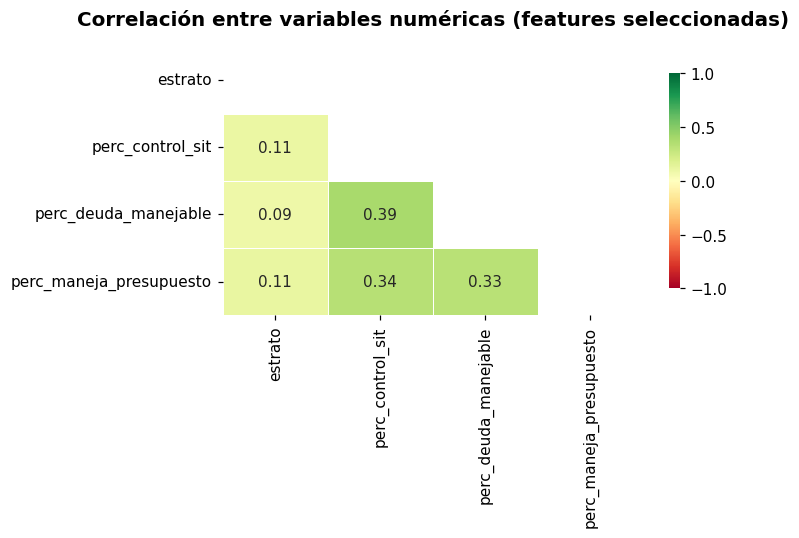

In [52]:
# 3.4 Correlación entre variables numéricas/ordinales
cols_num = ['estrato', 'perc_control_sit', 'perc_deuda_manejable', 'perc_maneja_presupuesto']
corr_df  = df[cols_num].apply(pd.to_numeric, errors='coerce').corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre variables numéricas (features seleccionadas)', pad=14)
plt.tight_layout()
plt.savefig('../docs/viz_04_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 4 — Imputación por estrategia estadística

| Columna | Razón del nulo | Valor imputado |
|---|---|---|
| `perc_maneja_presupuesto`, `perc_deuda_manejable`, `perc_control_sit` | NS/NR en escala 1-5 | Mediana (valor central) |
| `comp_atraso_pagos` | NS/NR ordinal | Mediana |
| `estrato`, `rango_ingresos`, `frec_ingresos`, `miembros_empleo_estable` | NS/NR / No responde | Mediana / moda |
| `ahorro_metodo`, `plan_jubilacion`, `solicito_credito` | NS/NR → se imputará con la categoría más frecuente en encoding |


In [53]:
# Escalas ordinales T405_x: NS/NR residuales → mediana
for col in ['perc_maneja_presupuesto', 'perc_deuda_manejable', 'perc_control_sit']:
    n = df[col].isnull().sum()
    if n > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'[{col}] {n} nulos → mediana ({med:.0f})')

# Estrato → numérico y mediana para NaN
df['estrato'] = pd.to_numeric(df['estrato'], errors='coerce')
n = df['estrato'].isnull().sum()
if n > 0:
    med_est = df['estrato'].median()
    df['estrato'] = df['estrato'].fillna(med_est)
    print(f'[estrato] {n} nulos → mediana ({med_est:.0f})')

print(f'\nNulos restantes: {df.isnull().sum().sum()}')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())


[perc_maneja_presupuesto] 91 nulos → mediana (3)
[perc_deuda_manejable] 106 nulos → mediana (4)
[perc_control_sit] 101 nulos → mediana (4)
[estrato] 286 nulos → mediana (2)

Nulos restantes: 1528
fragilidad_financiera      383
rango_ingresos             241
frec_ingresos              399
prod_cuenta_ahorro           4
prod_tarjeta_debito          3
solicito_credito            78
nivel_educativo              6
miembros_empleo_estable     31
nivel_fragilidad           383


---
## 5 — Codificación y preparación para modelado

Se separa `df_model` (sin NS/NR en la variable objetivo), se codifican las variables
y se divide en **train / test** con semilla fija (80% / 20%).

> **Nota anti-fuga de datos:** el escalado (`StandardScaler`) se ajustará
> **solo** sobre el conjunto de entrenamiento en `03_modelado.ipynb`.
> La selección de modelo y tuning de hiperparámetros se realizan mediante
> **validación cruzada** sobre el train, sin tocar el test.


In [54]:
# 5.1 Variable objetivo → etiqueta numérica ordinal
mapa_fragilidad = {
    'Una semana': 3, 'Dos semanas': 3,   # ALTA
    'Un mes'    : 2, 'Tres meses' : 2,   # MEDIA
    'Seis meses': 1, 'Un año'     : 1,   # BAJA
    'Más de un año': 1,
}
df['fragilidad_label'] = df['fragilidad_financiera'].map(mapa_fragilidad)
df_model = df.dropna(subset=['fragilidad_label']).copy()

print(f'Registros totales        : {len(df):,}')
print(f'Registros para modelar   : {len(df_model):,}')
print(f'Descartados (NS/NR obj.) : {len(df) - len(df_model):,}')
print()
print('Distribución de clases:')
etiquetas = {1:'Baja  (≥6 meses)', 2:'Media (1-3 meses)', 3:'Alta  (≤2 semanas)'}
for k, v in df_model['fragilidad_label'].value_counts().sort_index().items():
    print(f'  Clase {int(k)} — {etiquetas[k]}: {v:,} ({v/len(df_model)*100:.1f}%)')

Registros totales        : 5,610
Registros para modelar   : 5,227
Descartados (NS/NR obj.) : 383

Distribución de clases:
  Clase 1 — Baja  (≥6 meses): 1,165 (22.3%)
  Clase 2 — Media (1-3 meses): 2,056 (39.3%)
  Clase 3 — Alta  (≤2 semanas): 2,006 (38.4%)


In [55]:
# 5.2 Codificación de las 20 features

# ── A) Variables binarias (Sí/No → 1/0) ─────────────────────────────────────
for col in COLS_BIN:
    df_model[col] = df_model[col].map({'Sí': 1, 'No': 0})

# ── B) Ordinales con escala de frecuencia (Nunca=1 … Siempre=5) ──────────────
mapa_frecuencia = {'Nunca':1,'Casi nunca':2,'A veces':3,'Casi siempre':4,'Siempre':5}

# Frecuencia de atraso en pagos (T402_3)
df_model['comp_atraso_pagos'] = df_model['comp_atraso_pagos'].map(mapa_frecuencia)
df_model['comp_atraso_pagos'] = df_model['comp_atraso_pagos'].fillna(df_model['comp_atraso_pagos'].median())

# Frecuencia de que le falta dinero al final del mes (T402_2) — sin NaN en raw
df_model['comp_falta_dinero'] = df_model['comp_falta_dinero'].map(mapa_frecuencia)

# ── C) Ordinales con escala de capacidad/acuerdo (Nada=1 … Muy bien=5) ───────
# T401_1 y T401_2: "Nada / Muy poco / En cierta medida / Totalmente / Muy bien"
# Sin NS/NR en el dataset (5,610 valores completos en raw)
mapa_capacidad = {'Nada':1,'Muy poco':2,'En cierta medida':3,'Totalmente':4,'Muy bien':5}

df_model['perc_puede_imprevisto'] = df_model['perc_puede_imprevisto'].map(mapa_capacidad)
df_model['perc_asegura_futuro']   = df_model['perc_asegura_futuro'].map(mapa_capacidad)

# ── D) Escalas numéricas T405_x (ya convertidas a numérico en paso 2.2) ─────
for col in ['perc_maneja_presupuesto', 'perc_deuda_manejable', 'perc_control_sit']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# ── E) Nivel educativo (0=Ninguno … 6=Posgrado) ──────────────────────────────
mapa_edu = {'Ninguno':0,'Primaria':1,'Secundaria':2,
            'Técnico':3,'Tecnólogos':4,'Universitarios':5,'Posgrado':6}
df_model['nivel_educativo'] = df_model['nivel_educativo'].map(mapa_edu)
df_model['nivel_educativo'] = df_model['nivel_educativo'].fillna(df_model['nivel_educativo'].median())

# ── F) Rango de ingresos (1=<250k … 10=>5M) ──────────────────────────────────
mapa_ingresos = {
    'Menos de 250.000':1,'Entre 250.001 y 500.000':2,'Entre 500.001 y 750.000':3,
    'Entre 750.001 y 1.000.000':4,'Entre 1.000.001 y 1.500.000':5,
    'Entre 1.500.001 y 2.000.000':6,'Entre 2.000.001 y 3.000.000':7,
    'Entre 3.000.001 y 4.000.000':8,'Entre 4.000.001 y 5.000.000':9,'Más de 5.000.000':10,
}
df_model['rango_ingresos'] = df_model['rango_ingresos'].map(mapa_ingresos)
df_model['rango_ingresos'] = df_model['rango_ingresos'].fillna(df_model['rango_ingresos'].median())

# ── G) Frecuencia de ingresos (0=Irregular … 4=Mensual) ──────────────────────
mapa_frec_ing = {'Irregularmente':0,'Diario':1,'Semanal':2,'Quincenal':3,'Mensual':4}
df_model['frec_ingresos'] = df_model['frec_ingresos'].map(mapa_frec_ing)
df_model['frec_ingresos'] = df_model['frec_ingresos'].fillna(df_model['frec_ingresos'].median())

# ── H) Miembros del hogar con empleo estable (0=Ninguno, 1=Uno, 2=Dos o más) ─
mapa_empleo = {'Ninguno':0,'Uno':1,'Dos o más':2}
df_model['miembros_empleo_estable'] = df_model['miembros_empleo_estable'].map(mapa_empleo)
df_model['miembros_empleo_estable'] = df_model['miembros_empleo_estable'].fillna(1)

# ── I) Uso/acceso a crédito (0=sin crédito … 3=varios créditos activos) ───────
mapa_credito = {
    'No y tampoco tengo otros créditos': 0,
    'No, pero ya tengo un crédito (incluyendo tarjeta de crédito o crédito rotativo)': 1,
    'Sí y fue la primera vez que solicitó uno': 2,
    'Sí y además tengo otros créditos': 3,
}
df_model['solicito_credito'] = df_model['solicito_credito'].map(mapa_credito)
df_model['solicito_credito'] = df_model['solicito_credito'].fillna(0)

# ── J) Binarias derivadas ─────────────────────────────────────────────────────
NO_AHORRA = 'No guardo, ni ahorro, ni invierto, ni separo'
df_model['ahorra'] = df_model['ahorro_metodo'].apply(
    lambda v: 0 if pd.isnull(v) or str(v).strip() == NO_AHORRA else 1
)
df_model.drop(columns=['ahorro_metodo'], inplace=True)

NO_PLAN_JUB = 'No estoy pensando en eso aún'
df_model['plan_jubilacion'] = df_model['plan_jubilacion'].apply(
    lambda v: 0 if pd.isnull(v) or str(v).strip() == NO_PLAN_JUB else 1
)

# ── K) Género → OHE ──────────────────────────────────────────────────────────
df_model = pd.get_dummies(df_model, columns=['genero'], drop_first=True, dtype=int)

# ── L) Limpiar columnas de texto residuales ───────────────────────────────────
df_model.drop(columns=['fragilidad_financiera','nivel_fragilidad'], inplace=True, errors='ignore')
cols_texto = [c for c in df_model.columns if c != 'fragilidad_label' and df_model[c].dtype == object]
if cols_texto:
    print(f'⚠ Columnas texto residuales: {cols_texto}')
    df_model.drop(columns=cols_texto, inplace=True)

print(f'Dataset para modelar: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas')
print(f'\nFeatures ({df_model.shape[1]-1}):')
print([c for c in df_model.columns if c != 'fragilidad_label'])
print(f'\nNulos restantes: {df_model.isnull().sum().sum()}')


Dataset para modelar: 5,227 filas x 21 columnas

Features (20):
['rango_ingresos', 'frec_ingresos', 'plan_jubilacion', 'gasto_entretenimiento', 'gasto_prod_financieros', 'prod_cuenta_ahorro', 'prod_tarjeta_debito', 'comp_falta_dinero', 'comp_atraso_pagos', 'solicito_credito', 'perc_puede_imprevisto', 'perc_asegura_futuro', 'perc_maneja_presupuesto', 'perc_deuda_manejable', 'perc_control_sit', 'nivel_educativo', 'miembros_empleo_estable', 'estrato', 'ahorra', 'genero_Masculino']

Nulos restantes: 7


In [56]:
# 5.3 Separación train / test  (80% / 20%)
# Semilla fija → resultados reproducibles
# stratify=y → mantiene la distribución de clases en ambos conjuntos

X = df_model.drop(columns=['fragilidad_label'])
y = df_model['fragilidad_label'].astype(int)

# Imputar NaN residuales en features numéricos
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

n = len(X)
print(f"Total  : {n:,} registros")
print(f"Train  : {len(X_train):,}  ({len(X_train)/n*100:.0f}%)  ← entrenamiento + CV interna")
print(f"Test   : {len(X_test):,}   ({len(X_test)/n*100:.0f}%)  ← evaluación final (holdout)")
print()
print("Distribución de clases en train (verificar estratificación):")
for k, v in y_train.value_counts().sort_index().items():
    print(f"  Clase {k}: {v:,} ({v/len(y_train)*100:.1f}%)")


Total  : 5,227 registros
Train  : 4,181  (80%)  ← entrenamiento + CV interna
Test   : 1,046   (20%)  ← evaluación final (holdout)

Distribución de clases en train (verificar estratificación):
  Clase 1: 932 (22.3%)
  Clase 2: 1,644 (39.3%)
  Clase 3: 1,605 (38.4%)


---
## 6 — Guardado del dataset procesado

In [57]:
ruta_limpio = RUTA_PROCESSED / 'dataset_limpio.csv'
df_model.to_csv(ruta_limpio, index=False, encoding='utf-8')
print(f'dataset_limpio.csv  → {df_model.shape}')

train_df = X_train.copy(); train_df['fragilidad_label'] = y_train
test_df  = X_test.copy();  test_df['fragilidad_label']  = y_test

train_df.to_csv(RUTA_PROCESSED / 'train.csv', index=False, encoding='utf-8')
test_df.to_csv( RUTA_PROCESSED / 'test.csv',  index=False, encoding='utf-8')

print(f'train.csv           → {train_df.shape}  (80%)')
print(f'test.csv            → {test_df.shape}   (20%)')
print()
print('Archivos en data/processed/:')
for f in sorted(RUTA_PROCESSED.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')


dataset_limpio.csv  → (5227, 21)
train.csv           → (4181, 21)  (80%)
test.csv            → (1046, 21)   (20%)

Archivos en data/processed/:
  dataset_limpio.csv  (342 KB)
  test.csv  (67 KB)
  train.csv  (266 KB)
  validacion.csv  (45 KB)


---
## Resumen del pipeline

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Carga de las 20 features (Top 20 Cramér's V) | 21 columnas raw → dataset enfocado |
| 2a | NS/NR → NaN (6 formatos) | Nulos reales marcados |
| 2b | T405_x string → numérico (escala 1-5) | 3 escalas de percepción listas |
| 2c | Sí/No → normalización consistente | 4 binarias en formato uniforme |
| 2d | Estrato → numérico, mediana para NaN | Variable lista para modelado |
| 3 | EDA (4 visualizaciones) | Guardadas en docs/ |
| 4 | Imputación (mediana / moda por variable) | Sin nulos residuales |
| 5 | Codificación + split 80/20 | 20 features numéricas, semilla 42 |
| 6 | Guardado | train.csv, test.csv |

**Output:** data/processed/ con archivos listos para 03_modelado.ipynb.
